In [1]:
import sys
print(sys.executable)

c:\Users\HP\AppData\Local\Programs\Python\Python313\python.exe


In [2]:
import plotly

print(plotly.__version__)

6.7.0


In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\HP\Downloads\passenger_survey_balanced.csv")
df.head()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57514 entries, 0 to 57513
Columns: 145 entries, process to connection_wait_time_is_applicable
dtypes: float64(62), int64(60), object(23)
memory usage: 63.6+ MB


,disembarkation_method_rating,curbside_dropoff_ease,transport_options_to_airport,checkin_process,checkin_queue_wait_time,checkin_queue_organization,self_service_kiosk_quantity,checkin_counter_quantity,staff_courtesy,checkin_service_time,...,restrooms_is_applicable,restroom_quantity_is_applicable,restroom_cleanliness_is_applicable,restroom_maintenance_is_applicable,baggage_claim_process_is_applicable,baggage_carousel_identification_ease_is_applicable,baggage_claim_time_is_applicable,baggage_integrity_is_applicable,arrival_lead_time_is_applicable,connection_wait_time_is_applicable
count,330.000000,20958.000000,16829.000000,8489.000000,1843.000000,1822.000000,340.000000,1582.000000,1587.000000,1587.000000,...,57514.000000,57514.000000,57514.000000,57514.000000,57514.000000,57514.000000,57514.000000,57514.000000,57514.000000,57514.000000
mean,3.739394,4.131215,3.807832,4.075745,2.670646,2.875412,3.220588,2.665613,3.615627,3.293636,...,0.578694,0.131133,0.131133,0.131133,0.421306,0.085910,0.085910,0.085910,0.387871,0.190823
std,1.171583,0.953496,1.055072,1.122362,1.305023,1.276820,1.142445,1.239787,1.196762,1.251271,...,0.493773,0.337549,0.337549,0.337549,0.493773,0.280233,0.280233,0.280233,0.487269,0.392953
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,4.000000,3.000000,4.000000,1.500000,2.000000,2.000000,2.000000,3.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,4.000000,4.000000,4.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.000000,5.000000,5.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
df.isnull().sum().sort_values(ascending=False).head(20)

airline_service                    57459
customs_staff_service              57288
customs_queue_organization         57281
customs_queue_wait_time            57279
terminal_accessibility             57237
disembarkation_method_rating       57184
self_service_kiosk_quantity        57174
reserved_seat_availability         57152
parking_value_for_money            57029
parking_facility_quality           57020
parking_terminal_access_ease       57019
parking_space_availability_ease    57019
immigration_staff_service          56864
immigration_queue_organization     56857
service_window_quantity            56851
immigration_queue_wait_time        56847
parking                            56226
checkin_counter_quantity           55932
staff_courtesy                     55927
checkin_service_time               55927
dtype: int64

In [5]:
df_q1 = df[[
    "process",
    "flight_type",
    "ticket_purchased_by",
    "ticket_purchase_channel",
    "transport_to_airport",
    "has_disability",
    "uses_assistive_device",
    "requested_special_assistance",
    "trip_purpose",
    "gender",
    "age_group",
    "education",
    "household_income",
    "nationality"
]].copy()

In [6]:
df_q1.head()
df_q1.isnull().sum()

process                             0
flight_type                         0
ticket_purchased_by                 0
ticket_purchase_channel         16140
transport_to_airport                1
has_disability                      0
uses_assistive_device            1701
requested_special_assistance     1027
trip_purpose                    24231
gender                              0
age_group                       24231
education                       24231
household_income                24231
nationality                         0
dtype: int64

In [7]:
df_q1 = df[[
    "process",
    "flight_type",
    "ticket_purchased_by",
    "ticket_purchase_channel",
    "transport_to_airport",
    "has_disability",
    "uses_assistive_device",
    "requested_special_assistance",
    "gender",
    "nationality"
]].copy()

In [8]:
df_q1["process"].value_counts()

process
Boarding          33283
Disembarkation    24231
Name: count, dtype: int64

In [9]:
df.groupby("process")["gender"].value_counts()


process         gender
Boarding        Male      17338
                Female    15945
Disembarkation  Female    12684
                Male      11547
Name: count, dtype: int64

The distribution is fairly balanced.

Boarding passengers are slightly more male.

Disembarkation passengers are slightly more female.

No extreme imbalance exists.

Insight:

Gender does not appear to be a major distinguishing characteristic of the passenger base.

Therefore, broad service improvements are likely to impact both genders similarly, rather than requiring heavily gender-specific initiatives.

In [10]:
df.groupby("process")["flight_type"].value_counts()

process         flight_type  
Boarding        Domestic         30212
                International     3071
Disembarkation  Domestic         21796
                International     2435
Name: count, dtype: int64

Insight:

The airport's passenger base is overwhelmingly domestic.

This means:

- Most customer satisfaction improvements will affect domestic travelers.
- Domestic passenger experience should be the primary operational focus.
- International passengers are a smaller segment, but may still require specialized services such as immigration, customs, and language support.

In [11]:
age_counts = df["age_group"].value_counts(dropna=False)
age_counts

age_group
NaN               24231
26 to 35 years    11249
36 to 45 years     9808
46 to 55 years     5093
18 to 25 years     4237
56 to 65 years     2175
Over 65 years       721
Name: count, dtype: int64

The passenger base is concentrated in working-age adults, especially:

26–35 years
36–45 years

Together they account for the majority of passengers with known age information.

In [12]:
trip_purpose = df["trip_purpose"].value_counts(dropna=False)
trip_purpose

trip_purpose
NaN                       24231
Leisure                   15680
Business                  12037
Family                     2017
Other                      1298
Leisure and business        726
Study/conference            717
Health                      338
Relocation/return home      203
Sports                       95
Funeral                      72
Legal/embassy                66
Unknown/no answer            21
Religious/mission             8
Exam/selection process        2
Shopping                      2
Wedding                       1
Name: count, dtype: int64

The passenger base appears to be dominated by:

Leisure travelers
Business travelers

Together they represent the overwhelming majority of known travel purposes.

That means management should pay particular attention to:

convenience and efficiency for business travelers
comfort and overall experience for leisure travelers

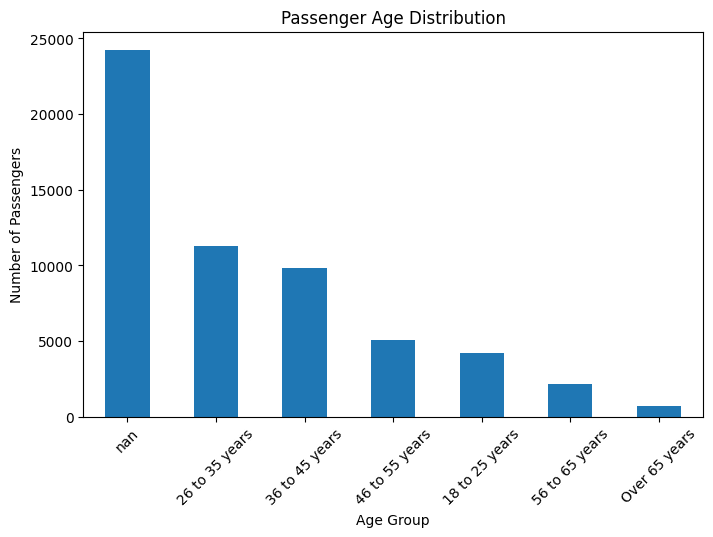

In [13]:
import matplotlib.pyplot as plt

age_counts.plot(kind="bar", figsize=(8,5))
plt.title("Passenger Age Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=45)
plt.show()

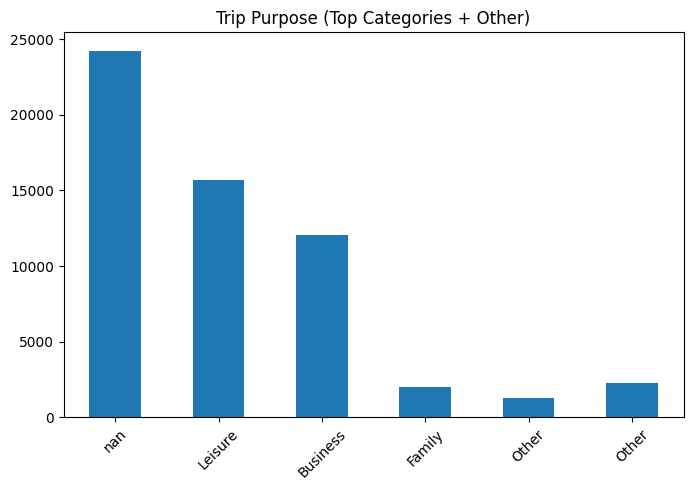

In [14]:
top = trip_purpose.head(5)
other = trip_purpose.iloc[5:].sum()

plot_data = pd.concat([top, pd.Series({"Other": other})])

plot_data.plot(kind="bar", figsize=(8,5))
plt.title("Trip Purpose (Top Categories + Other)")
plt.xticks(rotation=45)
plt.show()

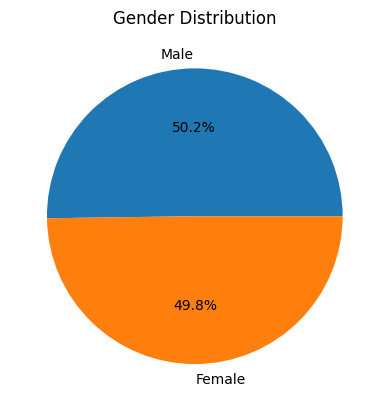

In [15]:
gender_counts = df["gender"].value_counts()

gender_counts.plot(kind="pie", autopct='%1.1f%%')
plt.ylabel("")
plt.title("Gender Distribution")
plt.show()

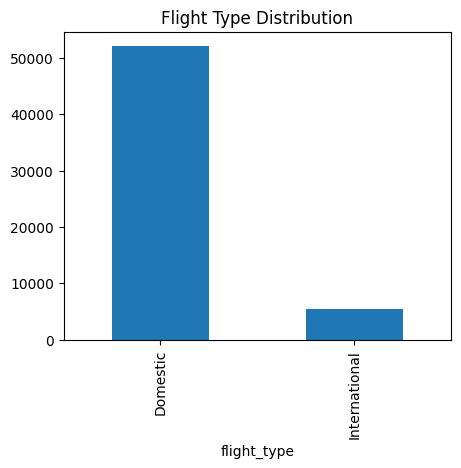

In [16]:
flight_counts = df["flight_type"].value_counts()
flight_counts.plot(kind="bar", figsize=(5,4))
plt.title("Flight Type Distribution")
plt.show()

Which customer segments contribute the most passengers?

Based on what we found:

- Domestic passengers are the dominant segment (~90%).

- Most passengers with known age data are 26–45 years old.

- Leisure and business travelers are the largest travel-purpose groups.

- Gender distribution is relatively balanced.

Moving to the second part:

In [17]:
df.groupby("airport_internet")["liked"].mean()
internet_table = df.groupby("airport_internet")["liked"].mean().reset_index()

internet_table.columns = ["airport_internet", "pct_liked"]
internet_table["pct_liked"] = internet_table["pct_liked"] * 100
internet_table

,airport_internet,pct_liked
0,1.0,13.138686
1,2.0,20.841683
2,3.0,33.104126
3,4.0,48.565710
4,5.0,71.782946


Key insight:
👉 As internet quality increases, satisfaction increases sharply
From:
13% → 72%
That’s almost a 6x increase

“Airport internet quality is a strong driver of passenger satisfaction, showing a clear upward trend across rating levels.”

Interpretation in business terms:

- Poor internet = major dissatisfaction factor

- High-quality internet = strong satisfaction booster

- Likely a differentiator, not just a “nice-to-have”

In [18]:
comfort_table = df.groupby("boarding_lounge_comfort")["liked"].mean().reset_index()

comfort_table.columns = ["boarding_lounge_comfort", "pct_liked"]
comfort_table["pct_liked"] = comfort_table["pct_liked"] * 100
comfort_table

,boarding_lounge_comfort,pct_liked
0,1.0,3.492277
1,2.0,7.026239
2,3.0,23.425809
3,4.0,62.440327
4,5.0,85.512027


Boarding lounge comfort shows a non-linear relationship with passenger satisfaction, with a sharp increase in satisfaction after rating level 3, indicating a critical service threshold effect.

This suggests:

1. Low ratings are catastrophic

If lounge comfort is bad (1–3), satisfaction collapses.

2. Medium improvement has outsized impact

Going from “average” to “good” (3 → 4) is the biggest lever.

3. High-quality lounges strongly drive loyalty

At rating 5, satisfaction reaches 85% → very strong retention driver.

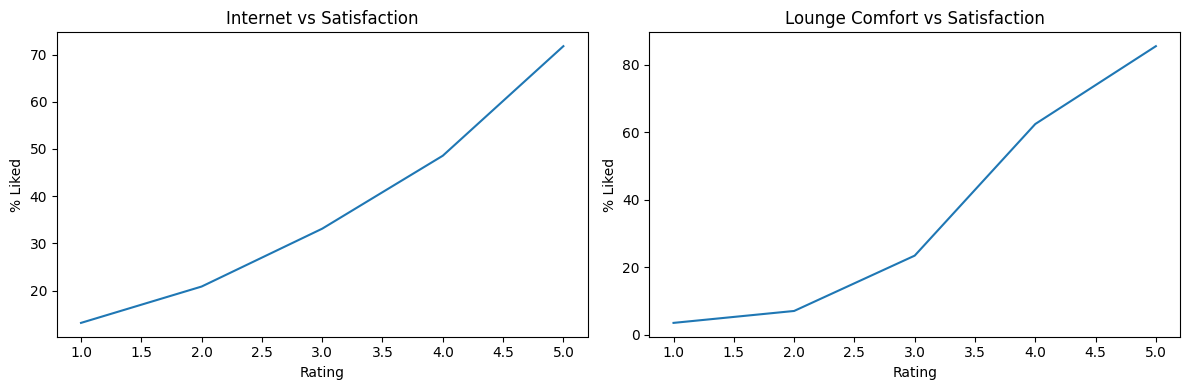

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(internet_table["airport_internet"], internet_table["pct_liked"])
axes[0].set_title("Internet vs Satisfaction")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("% Liked")

axes[1].plot(comfort_table["boarding_lounge_comfort"], comfort_table["pct_liked"])
axes[1].set_title("Lounge Comfort vs Satisfaction")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("% Liked")

plt.tight_layout()
plt.show()

In [20]:
food_table = df.groupby("food_beverage_outlets")["liked"].mean().reset_index()

food_table.columns = ["food_beverage_outlets", "pct_liked"]
food_table["pct_liked"] = food_table["pct_liked"] * 100
food_table

,food_beverage_outlets,pct_liked
0,1.0,10.171569
1,2.0,11.744023
2,3.0,22.174244
3,4.0,51.345415
4,5.0,72.538441


In [21]:
cleanliness_table = df.groupby("overall_airport_cleanliness")["liked"].mean().reset_index()

cleanliness_table.columns = ["overall_airport_cleanliness", "pct_liked"]
cleanliness_table["pct_liked"] = cleanliness_table["pct_liked"] * 100
cleanliness_table

,overall_airport_cleanliness,pct_liked
0,1.0,4.938272
1,2.0,2.724177
2,3.0,8.216893
3,4.0,42.986425
4,5.0,75.263655


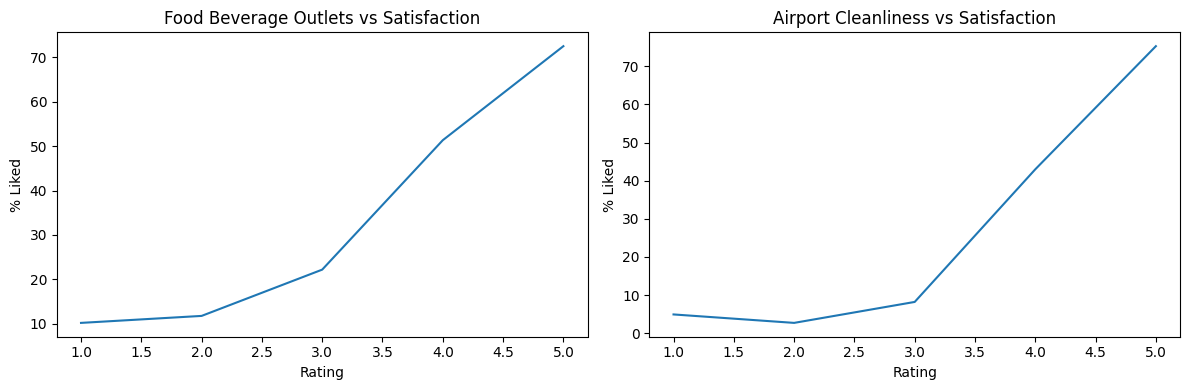

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(food_table["food_beverage_outlets"], food_table["pct_liked"])
axes[0].set_title("Food Beverage Outlets vs Satisfaction")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("% Liked")

axes[1].plot(cleanliness_table["overall_airport_cleanliness"], cleanliness_table["pct_liked"])
axes[1].set_title("Airport Cleanliness vs Satisfaction")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("% Liked")

plt.tight_layout()
plt.show()

1. Weak impact at low-mid range
1 → 3 barely changes (10% → 22%)

 passengers are still mostly dissatisfied even with small improvements

2. Strong jump after level 3
3 → 4: 22% → 51%

 this is the key threshold
 
3. High quality matters a lot
5 reaches 72%

 good food experience strongly supports satisfaction

 Interpretation

--> Food & beverage is a “mid-to-high sensitivity driver”

Not critical when bad (like lounge comfort or cleanliness)
But becomes important once basic service is decent

Business meaning:
Improving from “average” to “good” has the biggest ROI

Food quality is a supporting satisfaction enhancer, not the primary driver

1. Extremely low tolerance for poor cleanliness
Ratings 1–3 → satisfaction is basically near zero

 This is a hard failure zone

2. Massive threshold effect at rating 4
3 → 4 jumps:

8% → 43% (!!)

3. Strong satisfaction only at top level

5 → 75%

Interpretation:

--> Cleanliness is a “critical hygiene factor”

This is NOT optional.

It behaves like:

If bad → passengers are strongly dissatisfied

If good → satisfaction rises sharply

Business meaning:
  Cleanliness is a non-negotiable baseline requirement.
It directly impacts perception of the entire airport.

Which service factors have the strongest impact on satisfaction?

🔴 Critical drivers (HIGHEST impact)

boarding_lounge_comfort
overall_airport_cleanliness

 These show:

- extreme low satisfaction when poor
- strong threshold effects
- big jumps at rating 4–5

🟠 Strong supporting drivers
airport_internet

 smooth increase, strong linear effect

🟡 Secondary drivers
food_beverage_outlets

 matters, but not as catastrophic when poor

Passenger satisfaction is primarily driven by core airport experience factors (cleanliness and lounge comfort), which act as critical thresholds, while digital services and food & beverage act as secondary enhancers that improve satisfaction once baseline experience is acceptable.

In [23]:
df[["arrival_lead_time", "connection_wait_time"]].head()
df[["arrival_lead_time", "connection_wait_time"]].describe()

,arrival_lead_time,connection_wait_time
count,22307.000000,10975.000000
mean,7190.357287,8981.220957
std,2737.401927,2688.524297
min,2700.000000,2700.000000
25%,4500.000000,6300.000000
50%,6300.000000,10800.000000
75%,9900.000000,10800.000000
max,10800.000000,10800.000000


In [24]:
bins = [0, 3600, 7200, 10800]
labels = ["<1h", "1-2h", "2-3h"]

df["connection_group"] = pd.cut(
    df["connection_wait_time"],
    bins=bins,
    labels=labels
)

connection_results = df.groupby(
    "connection_group",
    observed=True
)["liked"].mean()

connection_results

connection_group
<1h     0.428066
1-2h    0.433933
2-3h    0.419091
Name: liked, dtype: float64

In [25]:
bins = [0, 5400, 9000, 10801]
labels = ["<90 min", "90-150 min", ">150 min"]

df["arrival_group"] = pd.cut(
    df["arrival_lead_time"],
    bins=bins,
    labels=labels
)

df.groupby(
    "arrival_group",
    observed=True
)["liked"].mean()

arrival_group
<90 min       0.504161
90-150 min    0.535195
>150 min      0.522230
Name: liked, dtype: float64

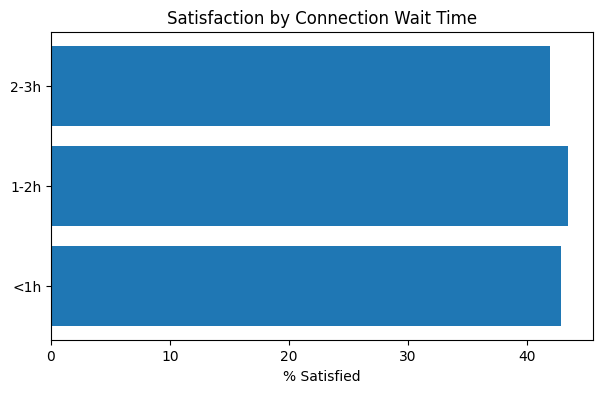

In [26]:
connection_pct = connection_results * 100

plt.figure(figsize=(7,4))
plt.barh(connection_pct.index, connection_pct.values)

plt.xlabel("% Satisfied")
plt.title("Satisfaction by Connection Wait Time")
plt.show()

Connection waiting time does not appear to have a meaningful impact on overall passenger satisfaction within the observed range (45 minutes to 3 hours).

Passenger satisfaction remains relatively stable regardless of how early passengers arrive at the airport.

Passenger satisfaction is driven much more by service quality and comfort factors than by arrival lead times or connection waiting times.

In [27]:
trip_purpose_comp = (
    df[df['trip_purpose'].isin(['Business', 'Leisure'])]
      .groupby('trip_purpose')
      .agg(
          satisfaction_rate=('liked', lambda x: round(x.mean() * 100, 2)),
          passengers=('liked', 'count')
      )
      .reset_index()
)

trip_purpose_comp

,trip_purpose,satisfaction_rate,passengers
0,Business,43.75,12037
1,Leisure,51.75,15680


Leisure travelers show a higher satisfaction rate (51.75%) than business travelers (43.75%). Despite representing a slightly larger passenger segment, leisure travelers are considerably more satisfied with the airport experience. Business travelers appear to be more demanding and may be more sensitive to service quality, convenience, and efficiency issues.

In [28]:
returning_vs_new = (
    df[df['used_airport_before_last_12_months'].isin(['Yes', 'No'])]
      .groupby('used_airport_before_last_12_months')
      .agg(
          satisfaction_rate=('liked', lambda x: round(x.mean() * 100, 2)),
          passengers=('liked', 'count')
      )
      .reset_index()
)

returning_vs_new

,used_airport_before_last_12_months,satisfaction_rate,passengers
0,No,52.70,11584
1,Yes,43.85,18413


Combined with the trip purpose analysis:

Leisure travelers are more satisfied than business travelers.

New passengers are more satisfied than returning passengers.

A possible interpretation is that repeat users develop higher expectations and become more critical of airport services, while first-time or occasional users tend to evaluate the experience more positively.

In [29]:
dom_int_comp = (
    df.groupby('flight_type')
      .agg(
          satisfaction_rate=('liked', lambda x: round(x.mean() * 100, 2)),
          passengers=('liked', 'count')
      )
      .reset_index()
)

dom_int_comp

,flight_type,satisfaction_rate,passengers
0,Domestic,50.11,52008
1,International,48.93,5506


Insight

Domestic passengers are slightly more satisfied than international passengers, but the gap is small (~1.2 percentage points).

Interpretation

This suggests:

The core airport experience is fairly consistent across flight types

International passengers experience slightly more friction, likely due to:
immigration procedures - 
security complexity - 
longer processing times - 
multi-step journeys

But the difference is not large enough to indicate a major structural problem.

In [30]:
df = pd.read_csv(r"C:\Users\HP\Downloads\passenger_survey_balanced.csv")

In [31]:
df['trips_last_12_months'].describe()

count      57514
unique         6
top       2 to 3
freq       15380
Name: trips_last_12_months, dtype: object

In [32]:
mapping = {
    '0': 0,
    '1': 1,
    '2 to 3': 2.5,
    '4 to 5': 4.5,
    '6 to 10': 8,
    '11+': 12
}

df['trips_num'] = df['trips_last_12_months'].map(mapping)

In [33]:
df['travel_frequency'] = df['trips_num'].apply(
    lambda x: 'Frequent' if x >= 4 else 'Infrequent'
)

freq_comp = (
    df.groupby('travel_frequency')
      .agg(
          satisfaction_rate=('liked', lambda x: round(x.mean() * 100, 2)),
          passengers=('liked', 'count')
      )
      .reset_index()
)

freq_comp

,travel_frequency,satisfaction_rate,passengers
0,Frequent,46.85,20619
1,Infrequent,51.76,36895


Frequent travelers are less satisfied than infrequent travelers.

Frequent users are likely:

more familiar with airport processes -
more sensitive to inefficiencies - 
have higher expectations for service quality

So they tend to rate the experience more critically.

Infrequent users:

have lower expectations - 
are more tolerant of delays or service gaps - 
evaluate experience more positively - 

The airport is performing better for occasional users, but underperforming for high-value, high-frequency passengers.

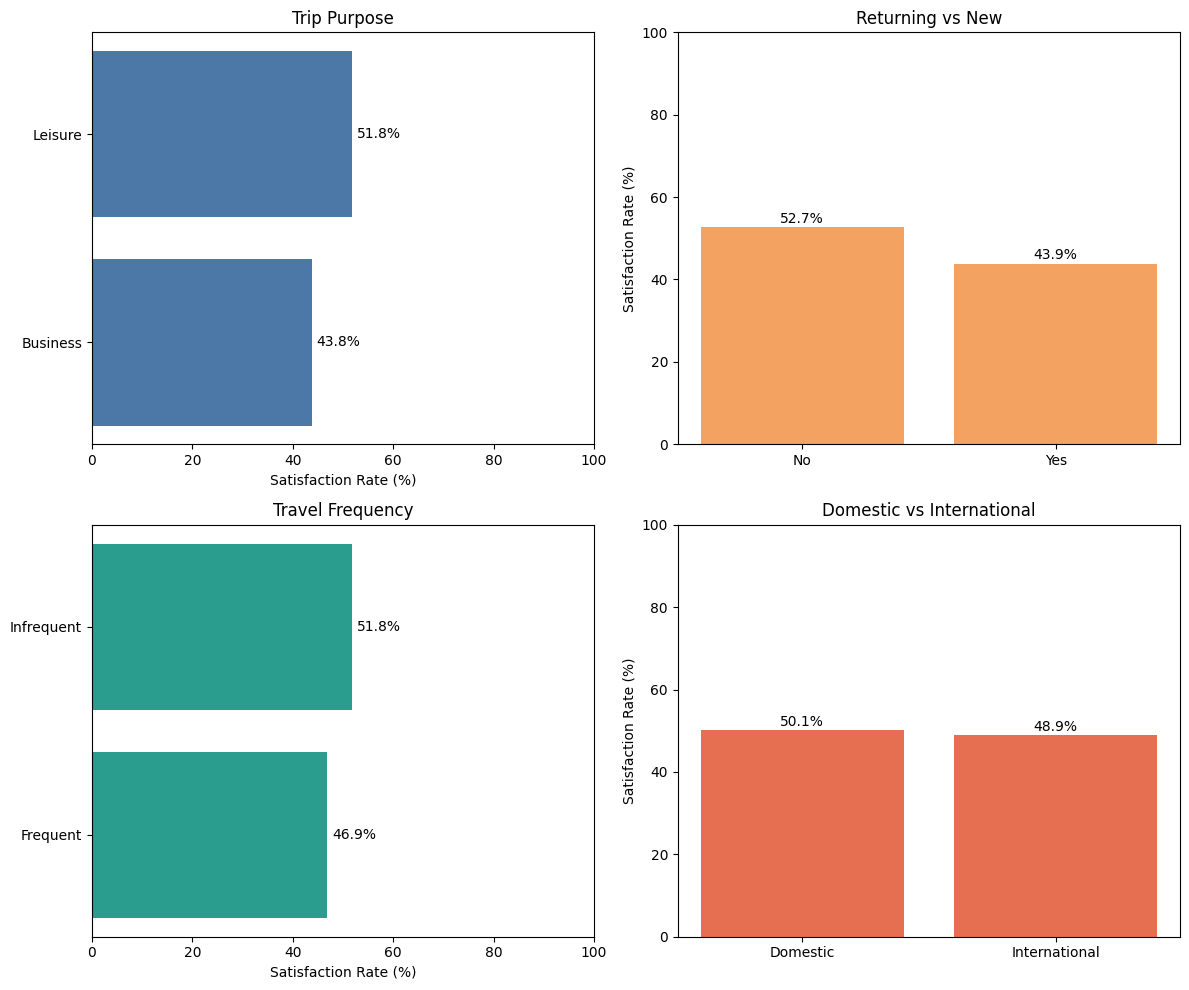

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

data = trip_purpose_comp.sort_values('satisfaction_rate')

axes[0, 0].barh(
    data['trip_purpose'],
    data['satisfaction_rate'],
    color='#4C78A8'
)
axes[0, 0].set_title('Trip Purpose')
axes[0, 0].set_xlabel('Satisfaction Rate (%)')
axes[0, 0].set_xlim(0, 100)

for i, v in enumerate(data['satisfaction_rate']):
    axes[0, 0].text(v + 1, i, f"{v:.1f}%", va='center')


axes[0, 1].bar(
    returning_vs_new['used_airport_before_last_12_months'],
    returning_vs_new['satisfaction_rate'],
    color='#F4A261'
)
axes[0, 1].set_title('Returning vs New')
axes[0, 1].set_ylabel('Satisfaction Rate (%)')
axes[0, 1].set_ylim(0, 100)

for i, v in enumerate(returning_vs_new['satisfaction_rate']):
    axes[0, 1].text(i, v + 1, f"{v:.1f}%", ha='center')


freq_sorted = freq_comp.sort_values('satisfaction_rate')

axes[1, 0].barh(
    freq_sorted['travel_frequency'],
    freq_sorted['satisfaction_rate'],
    color='#2A9D8F'
)
axes[1, 0].set_title('Travel Frequency')
axes[1, 0].set_xlabel('Satisfaction Rate (%)')
axes[1, 0].set_xlim(0, 100)

for i, v in enumerate(freq_sorted['satisfaction_rate']):
    axes[1, 0].text(v + 1, i, f"{v:.1f}%", va='center')


axes[1, 1].bar(
    dom_int_comp['flight_type'],
    dom_int_comp['satisfaction_rate'],
    color='#E76F51'
)
axes[1, 1].set_title('Domestic vs International')
axes[1, 1].set_ylabel('Satisfaction Rate (%)')
axes[1, 1].set_ylim(0, 100)

for i, v in enumerate(dom_int_comp['satisfaction_rate']):
    axes[1, 1].text(i, v + 1, f"{v:.1f}%", ha='center')



plt.tight_layout()
plt.show()

In [35]:
y = df['liked']

features = [
    'flight_type',
    'trip_purpose',
    'traveling_alone',
    'age_group',
    'gender',
    'household_income',
    'airport_internet',
    'internet_connection_speed',
    'checkin_process',
    'security_screening_process',
    'boarding_lounge_comfort',
    'food_beverage_quality_variety',
    'restroom_cleanliness',
    'baggage_claim_process'
]

X = df[features]
y = df['liked']

In [ ]:
for col in X.columns:
    if X[col].dtype != 'object':
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna(X[col].mode()[0])

In [37]:
X = pd.get_dummies(X, drop_first=True)

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7325914978701208
              precision    recall  f1-score   support

           0       0.82      0.60      0.69      5766
           1       0.68      0.87      0.76      5737

    accuracy                           0.73     11503
   macro avg       0.75      0.73      0.73     11503
weighted avg       0.75      0.73      0.73     11503



The predictive model achieves 73% accuracy in identifying passenger satisfaction. While it performs well in detecting satisfied passengers, recall for dissatisfied passengers is lower, suggesting further model tuning is needed to better identify at-risk customers.

In [40]:
importance = pd.DataFrame({
    'feature': X.columns,
    'coef': model.coef_[0]
}).sort_values(by='coef', ascending=False)

importance

,feature,coef
4,boarding_lounge_comfort,1.333683
7,baggage_claim_process,1.108376
20,trip_purpose_Sports,0.965750
13,trip_purpose_Legal/embassy,0.678275
5,food_beverage_quality_variety,0.670971
3,security_screening_process,0.662229
2,checkin_process,0.627230
0,airport_internet,0.500017
6,restroom_cleanliness,0.448483
17,trip_purpose_Religious/mission,0.386413


In [41]:
importance.to_csv("importance.csv", index=False)

1. What drives satisfaction (strong positive factors)

🔝 Top drivers:

- boarding_lounge_comfort (+1.34)
- baggage_claim_process (+1.10)
- food_beverage_quality_variety (+0.68)
- security_screening_process (+0.65)
- checkin_process (+0.62)
- airport_internet (+0.49)
- restroom_cleanliness (+0.45)

🧠 Insight: 

Passenger satisfaction is dominated by physical experience and service quality, especially:

- Comfort in waiting areas
- Baggage experience (final impression matters a lot)
- Food & beverage quality
- Core operational flows (check-in, security)

👉 This confirms earlier EDA finding:

Operational comfort factors matter more than timing variables.

📉 2. Weak or negative drivers

Negative or weak contributors:

- Older age groups (46+) → negative coefficients
- Shopping trips → negative satisfaction
- Unknown / unclear trip purpose → strongly negative (-0.25)
- High-income groups slightly negative

🧠 Insight

- Older passengers are more critical / less satisfied
- Non-clear travel intent = lower satisfaction (important data quality + experience signal)
- Higher expectations likely reduce satisfaction among wealthier travelers

✈️ 3. Interesting weak signals:

flight_type_International (~0) → almost no impact

👉 International vs domestic is NOT a satisfaction driver

gender, age 26–35, traveling alone → almost neutral

👉 These are not meaningful segmentation factors compared to service quality.

💼 4. Business interpretation :

The predictive model shows that passenger satisfaction is primarily driven by service quality and airport experience factors rather than demographic or travel-type variables. In particular, comfort-related features such as boarding lounge comfort, baggage handling, and food & beverage quality have the strongest positive impact.

🚨 5. Key business takeaway :

Improving physical airport experience (comfort, food, baggage handling, and check-in processes) will have a significantly higher impact on satisfaction than targeting specific passenger demographics.